11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training images: (60000, 28, 28)
Original testing images: (10000, 28, 28)

Training images used: (10000, 28, 28)
Testing images used: (2000, 28, 28)

After converting to RGB:
Training: (10000, 28, 28, 3)
Testing: (2000, 28, 28, 3)

After resizing:
Training: (10000, 96, 96, 3)
Testing: (2000, 96, 96, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 84s 315ms/step - accuracy: 0.8978 - loss: 0.3287 - val_accuracy: 0.9400 - val_loss: 0.1987
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 307ms/step - accuracy: 0.9591 - loss: 0.1257 - val_accuracy: 0.9445 - val_loss: 0.1870
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 70s 278ms/step - accuracy: 0.9682 - loss: 0.0931 - val_accuracy: 0.9480 - val_loss: 0.1610
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 283ms/step - accuracy: 0.9824 - loss: 0.0580 - val_accuracy: 0.9365 - val_loss: 0.2203
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 79s 314ms/step - accuracy: 0.9859 - loss: 0.0450 - val_accuracy: 0.9640 - val_loss: 0.1367

Transfer Learning Test Accuracy: 0.9555000066757202

Actual Digit: 7
Predicted Digit: 7


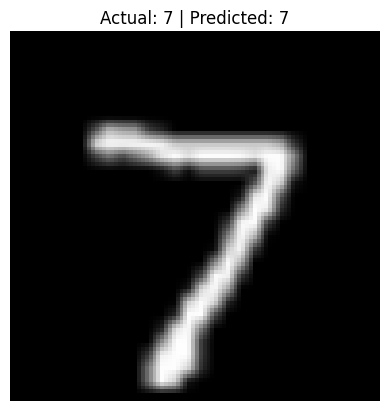

Name: Omkar Vaidya
Roll No.: 40


In [1]:
!pip install tensorflow

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.applications import MobileNetV2

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("Original training images:", x_train.shape)
print("Original testing images:", x_test.shape)

# USING A SMALLER DATASET As Transfer learning with the complete
# 60,000 images can take more time.

x_train = x_train[:10000]
y_train = y_train[:10000]

x_test = x_test[:2000]
y_test = y_test[:2000]

print("\nTraining images used:", x_train.shape)
print("Testing images used:", x_test.shape)

# CONVERT GRAYSCALE TO RGB
# Original: 28 x 28 x 1
# MobileNetV2 requires: height x width x 3

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
x_train = np.repeat(x_train, 3, axis=-1)
x_test = np.repeat(x_test, 3, axis=-1)


print("\nAfter converting to RGB:")
print("Training:", x_train.shape)
print("Testing:", x_test.shape)

# NORMALIZE
x_train = x_train / 255.0
x_test = x_test / 255.0

# RESIZE IMAGES
x_train = tf.image.resize(x_train, (96, 96))
x_test = tf.image.resize(x_test, (96, 96))

print("\nAfter resizing:")
print("Training:", x_train.shape)
print("Testing:", x_test.shape)

# LOAD PRE-TRAINED MOBILENETV2
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(96, 96, 3))

# FREEZE PRE-TRAINED LAYERS
base_model.trainable = False

# BUILD TRANSFER LEARNING MODEL
transfer_model = Sequential()
transfer_model.add(base_model)

# Converts feature maps into one vector
transfer_model.add(GlobalAveragePooling2D())

# New classification layer
transfer_model.add(Dense(128, activation="relu"))

# 10 digits = 10 output neurons
transfer_model.add(Dense(10, activation="softmax"))

# DISPLAY MODEL
transfer_model.summary()

# COMPILE MODEL
transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# TRAIN MODEL
history = transfer_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# EVALUATE MODEL
loss, accuracy = transfer_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTransfer Learning Test Accuracy:",
      accuracy)

# PREDICT ONE IMAGE
index = 0
image = x_test[index]
prediction = transfer_model.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)

predicted_digit = np.argmax(
    prediction
)

# DISPLAY RESULT
print("\nActual Digit:",
      y_test[index])
print("Predicted Digit:",
      predicted_digit)
plt.imshow(
    image.numpy()
)
plt.title(
    "Actual: " + str(y_test[index]) +
    " | Predicted: " + str(predicted_digit)
)
plt.axis("off")
plt.show()

print("Name: Omkar Vaidya")
print("Roll No.: 40")